# Hypothesis Testing: Frequentist and Bayesian

## *Workshop 6*  [![Open In Colab](https://github.com/oballinger/BASC0005/blob/main/colab-badge.png?raw=1)](https://colab.research.google.com/github/oballinger/BASC0005/blob/main/notebooks/W06.%20Hypothesis%20Testing.ipynb)

Last week we used the Central Limit Theorem to show that sample means are approximately normal, and that their spread is the **standard error**. This week we put that to work, following the lecture:

1. **Confidence intervals**: a range for a population value from a single sample
2. **The t-test**: is a difference between two groups (e.g. the gender pay gap) bigger than sampling error?
3. **A note of caution**: multiple comparisons, p-hacking and publication bias
4. **Bayes' theorem**: base rates and the prosecutor's fallacy
5. **Priors, likelihoods and posteriors**: estimating union membership again, the Bayesian way
6. **Confidence vs credible intervals**

We use the same U.S. Current Population Survey (CPS) extract as in Workshop 5.

### Aims

- Build and correctly interpret a 95% confidence interval
- Run the four steps of a hypothesis test with a two-sample t-test
- See, by simulation, why testing many hypotheses produces false positives, and why publishing only significant results inflates effect sizes
- Use Bayes' theorem to flip a conditional probability
- Update a Beta prior with binomial data, and compare a credible interval with a confidence interval

The core path takes roughly two hours. Sections marked **(Optional)** are extensions.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="white", font_scale=1.2)
plt.rcParams["figure.figsize"] = (10, 5)
rng = np.random.default_rng(42)   # fixed seed so your numbers match the website

We load the data and make the same choices as last week: the 2013 survey wave, income in \$ thousands, and people earning under \$200k. Remember what that means for the **population** we can talk about: 25-64 year-old wage earners in 2013 with incomes below \$200k.

In [2]:
cps = pd.read_csv("https://storage.googleapis.com/qm2/wk7/cps.csv")
df = cps[cps["year"] == 2013].copy()
df["income"] = df["incwage"] / 1000
df = df[df["income"] < 200]

# Union membership, as in Workshop 5: people asked the union question, 1 = member
unions = df[df["union"] != 0].copy()
unions["member"] = (unions["union"] == 2).astype(int)

print(f"{len(df):,} people; {len(unions):,} asked about union membership")

52,923 people; 8,697 asked about union membership


Reminder of the columns: `sex` (1 = male, 2 = female), `race` (1 = White non-Hispanic, 2 = Black non-Hispanic, 3 = Hispanic, 4 = Other), `sch` (years of schooling), `union` (0 = not asked, 1 = not covered, 2 = member, 3 = covered but not a member), `income` (\$k), `realhrwage` (hourly wage), `occupation` (`.` = missing).

**Why this matters beyond textbooks.** In the lecture's case study, a t-test is run on *every pixel* of a stack of free Sentinel-1 radar images, before and after an attack, to flag buildings whose radar return changed more than you'd expect from noise. The same logic, signal divided by noise, is what we build today.

## 1. Confidence intervals

In the real world we have **one** sample. Let's draw a random sample of 1,000 people and pretend it is all we have. The rest of `df` plays the role of the (normally unknown) population.

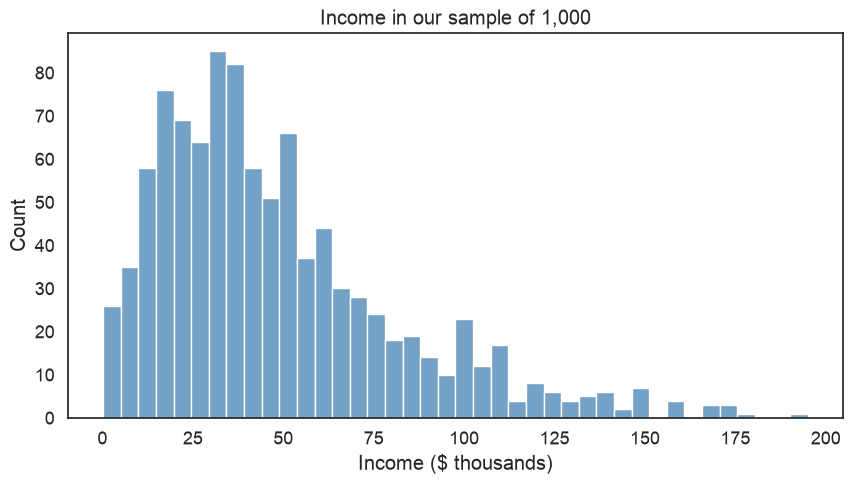

In [3]:
sample = df.sample(1000, random_state=5)

sns.histplot(sample["income"], bins=40, color="steelblue")
plt.title("Income in our sample of 1,000")
plt.xlabel("Income ($ thousands)")
plt.show()

From the CLT, the sample mean is approximately normal around the population mean, with standard error

$$SE = \frac{s}{\sqrt{n}}, \qquad s = \sqrt{\frac{1}{n-1}\sum_{i=1}^n (x_i-\bar{x})^2}$$

so a **95% confidence interval** is

$$\bar{x} \pm 1.96 \times SE$$

In [4]:
mean = sample["income"].mean()
s = sample["income"].std()
n = len(sample)
se = s / np.sqrt(n)
lower, upper = mean - 1.96 * se, mean + 1.96 * se

print(f"Sample mean {mean:.2f}, standard error {se:.2f}")
print(f"95% CI: {lower:.2f} to {upper:.2f}   (population mean: {df['income'].mean():.2f})")

Sample mean 48.00, standard error 1.08
95% CI: 45.88 to 50.12   (population mean: 46.75)


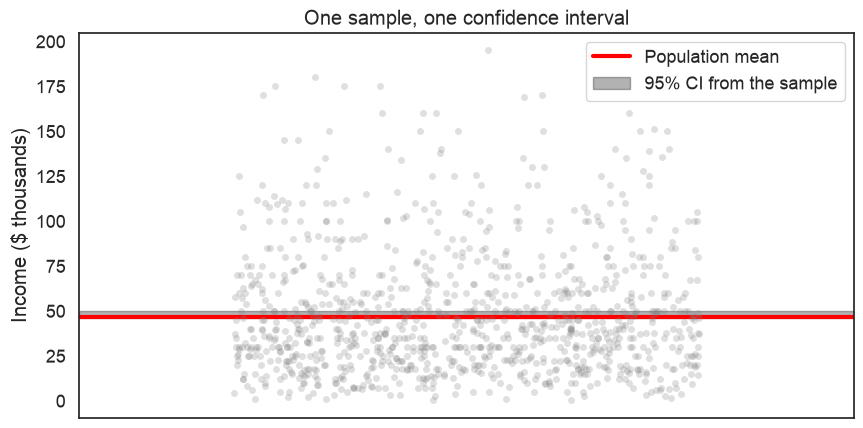

In [5]:
sns.stripplot(y=sample["income"], alpha=0.25, jitter=0.3, color="grey")
plt.axhline(df["income"].mean(), color="red", lw=3, label="Population mean")
plt.axhspan(lower, upper, color="black", alpha=0.3, label="95% CI from the sample")
plt.ylabel("Income ($ thousands)")
plt.title("One sample, one confidence interval")
plt.legend(); plt.show()

### What does "95%" actually mean?

It is tempting to say "there is a 95% chance the population mean is in this interval". Strictly, a frequentist can't say that: the population mean is a fixed number, and it either is or isn't in *this* interval. The 95% refers to the **procedure**: if we repeated the study many times, 95% of the intervals we built would contain the true value. Let's check by building 100 intervals from 100 different samples.

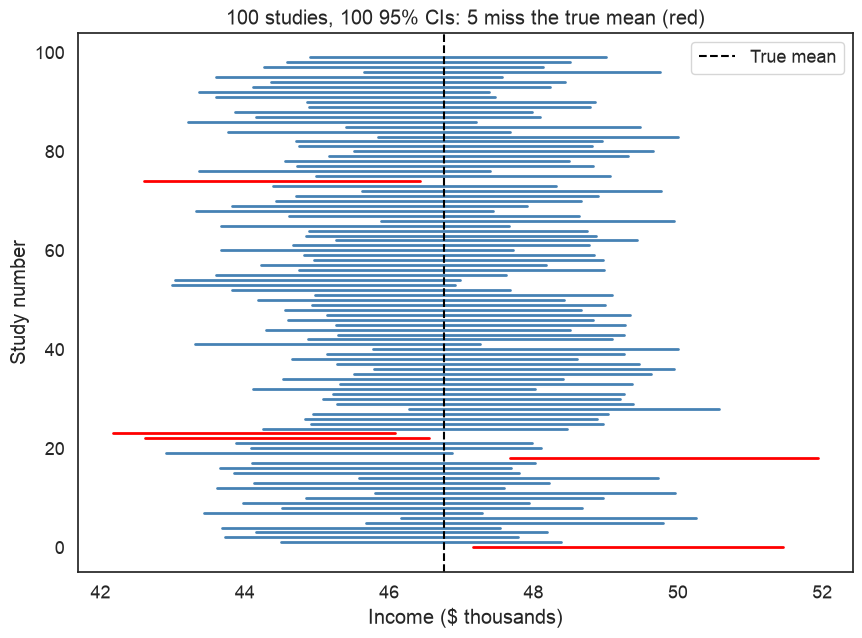

In [6]:
true_mean = df["income"].mean()
fig, ax = plt.subplots(figsize=(10, 7))
misses = 0
for i in range(100):
    x = df["income"].sample(1000, random_state=5000 + i)
    m, e = x.mean(), 1.96 * x.std() / np.sqrt(len(x))
    hit = (m - e <= true_mean <= m + e)
    misses += not hit
    ax.plot([m - e, m + e], [i, i], color="steelblue" if hit else "red", lw=2)
ax.axvline(true_mean, color="black", ls="--", label="True mean")
ax.set(xlabel="Income ($ thousands)", ylabel="Study number",
       title=f"100 studies, 100 95% CIs: {misses} miss the true mean (red)")
ax.legend(); plt.show()

### Exercise

0. On average you'd expect about 5 of 100 intervals to miss. Why isn't it always exactly 5?
1. Change the multiplier from 1.96 to 2.58 (a 99% interval). What happens to the width of the intervals and the number of misses?
2. Change the sample size from 1,000 to 100. What happens?
3. **Union membership.** For a proportion $\hat{p}$ the standard error is $\sqrt{\hat{p}(1-\hat{p})/n}$. Draw a sample of 1,000 from `unions` and compute a 95% CI for the union membership rate. Does it contain the population rate `unions["member"].mean()`?
4. Now do the same with a sample of 7 people. If no one in your sample is a member, what is your 95% CI? Does that seem sensible? (We come back to this in Section 5.)

In [7]:
# your code here

## 2. The t-test: is there a gender pay gap?

In our sample, men seem to earn more than women:

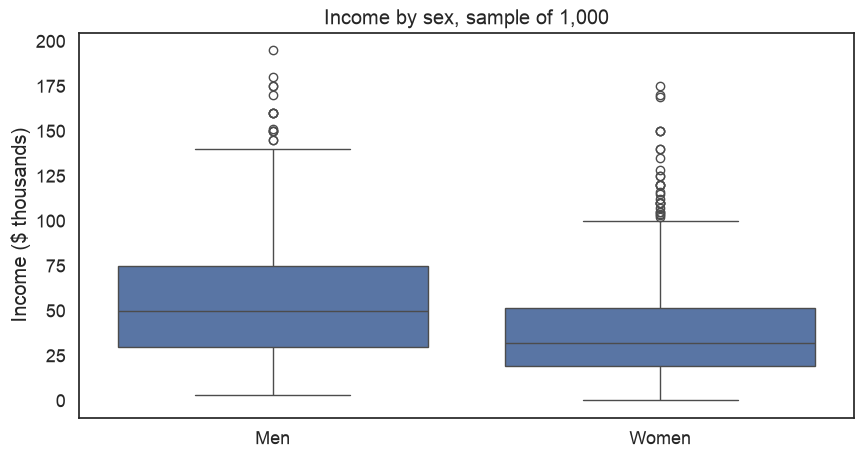

In [8]:
ax = sns.boxplot(data=sample, x="sex", y="income")
ax.set_xticks([0, 1], ["Men", "Women"])
ax.set(xlabel="", ylabel="Income ($ thousands)", title="Income by sex, sample of 1,000")
plt.show()

But even if there were no difference in the population, two random groups would never have *exactly* the same mean: that's **sampling error**. A hypothesis test asks whether the difference is bigger than sampling error can plausibly explain. Four steps:

### 1. State the hypotheses
* $H_0$: there is no difference in mean income between men and women ($\mu_{men} = \mu_{women}$)
* $H_a$: there is a difference ($\mu_{men} \neq \mu_{women}$)

### 2. Select an $\alpha$ level and critical value
With large samples the t distribution is essentially normal, so:
* $\alpha = 0.05$ (95% confidence): critical value **1.96**
* $\alpha = 0.01$ (99% confidence): critical value **2.58**

If the test statistic is further from zero than the critical value, we reject $H_0$.

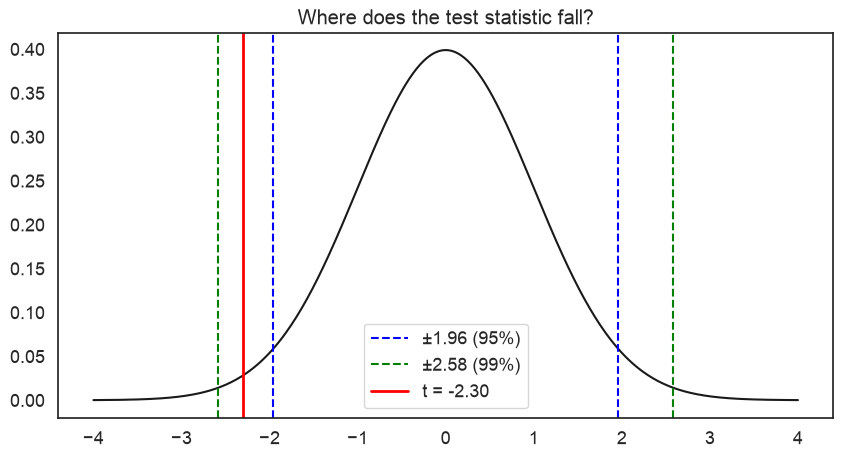

In [9]:
def plot_z(test_statistic):
    # Standard normal curve with 95% and 99% critical values, and a test statistic in red
    x = np.linspace(-4, 4, 400)
    plt.plot(x, stats.norm.pdf(x), "k")
    for cv, col, lab in [(1.96, "blue", "±1.96 (95%)"), (2.58, "green", "±2.58 (99%)")]:
        plt.axvline(-cv, color=col, ls="--", label=lab)
        plt.axvline(cv, color=col, ls="--")
    plt.axvline(np.clip(test_statistic, -4, 4), color="red", lw=2, label=f"t = {test_statistic:.2f}")
    plt.title("Where does the test statistic fall?")
    plt.legend(); plt.show()

plot_z(-2.3)   # would we reject H0 at 95%? at 99%?

### 3. Compute the test statistic

The (Welch) t statistic is the **signal** (difference in means) divided by the **noise** (the standard error of that difference):

$$t = \frac{\bar{x}_1-\bar{x}_2}{\sqrt{\frac{s^2_1}{n_1} + \frac{s^2_2}{n_2}}}$$

where $\bar{x}$ is a sample mean, $s^2$ a sample variance and $n$ a group size.

In [10]:
def manual_ttest(group1, group2):
    # Welch two-sample t statistic, computed by hand
    n1, n2 = len(group1), len(group2)
    m1, m2 = group1.mean(), group2.mean()
    v1, v2 = group1.var(), group2.var()
    se_diff = np.sqrt(v1 / n1 + v2 / n2)
    t = (m1 - m2) / se_diff
    print(f"Group 1: n={n1}, mean={m1:.2f}   Group 2: n={n2}, mean={m2:.2f}")
    print(f"Difference = {m1 - m2:.2f}, SE of difference = {se_diff:.2f}, t = {t:.2f}")
    return t

men = sample.loc[sample["sex"] == 1, "income"]
women = sample.loc[sample["sex"] == 2, "income"]
t = manual_ttest(men, women)

Group 1: n=501, mean=55.51   Group 2: n=499, mean=40.46
Difference = 15.05, SE of difference = 2.11, t = 7.13


### 4. Make a decision

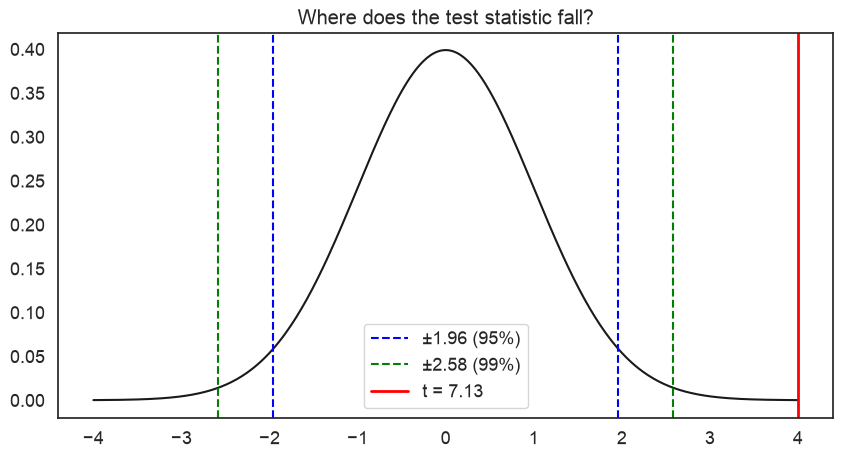

In [11]:
plot_z(t)

In practice you'd use a library, which also gives a **p-value**: the probability of a difference at least this extreme *if $H_0$ were true*.

In [12]:
res = stats.ttest_ind(men, women, equal_var=False)   # equal_var=False gives Welch's test, same as ours
print(f"t = {res.statistic:.2f}, p-value = {res.pvalue:.2g}")

t = 7.13, p-value = 2e-12


### Exercise

1. Write a one-paragraph interpretation of this test, in the style of the lecture ("In a sample of ... men and ... women, ..."). Be precise about what the p-value does and does not mean.
2. Plot the mean income of each group with 95% confidence intervals (hint: `sns.pointplot(data=sample, x="sex", y="income", errorbar=("ci", 95), linestyle="none", capsize=0.2)`). Do the intervals overlap?
3. Using samples of 500 people from `df`, test whether White non-Hispanic workers (`race == 1`) earn more than each of the other three groups. Which gap is largest? Which (if any) is not significant?
4. Is the union wage premium real? Test whether union members earn more than non-members, using all of `unions`.

In [13]:
# your code here

## 3. A note of caution: when significance misleads

A 5% significance level means that when $H_0$ is true, we'll wrongly reject it 5% of the time. That is fine for *one* test. But researchers rarely run just one.

### Spot the problem: do Aries earn more?

A researcher collects star signs for our sample of 1,000 (here we **assign them at random**, so there is by construction no real effect) and tests each sign against everyone else:

In [14]:
signs = ["Aries", "Taurus", "Gemini", "Cancer", "Leo", "Virgo", "Libra",
         "Scorpio", "Sagittarius", "Capricorn", "Aquarius", "Pisces"]
zodiac_rng = np.random.default_rng(7)
sample = sample.assign(sign=zodiac_rng.choice(signs, size=len(sample)))

results = []
for s in signs:
    inside = sample.loc[sample["sign"] == s, "income"]
    outside = sample.loc[sample["sign"] != s, "income"]
    r = stats.ttest_ind(inside, outside, equal_var=False)
    results.append({"sign": s, "diff": inside.mean() - outside.mean(), "p": r.pvalue})
results = pd.DataFrame(results).sort_values("p")

best = results.iloc[0]
print(f"HEADLINE: {best['sign']} earn ${abs(best['diff']):.1f}k {'more' if best['diff'] > 0 else 'less'} "
      f"than everyone else (p = {best['p']:.3f}, significant at 5%!)")
results.round(3)

HEADLINE: Aries earn $9.2k less than everyone else (p = 0.007, significant at 5%!)


,sign,diff,p
0,Aries,-9.193,0.007
4,Leo,6.910,0.117
8,Sagittarius,4.387,0.311
6,Libra,3.958,0.324
2,Gemini,-3.299,0.367
1,Taurus,-2.623,0.458
10,Aquarius,1.882,0.588
9,Capricorn,1.931,0.618
7,Scorpio,-1.849,0.662
5,Virgo,-1.586,0.668


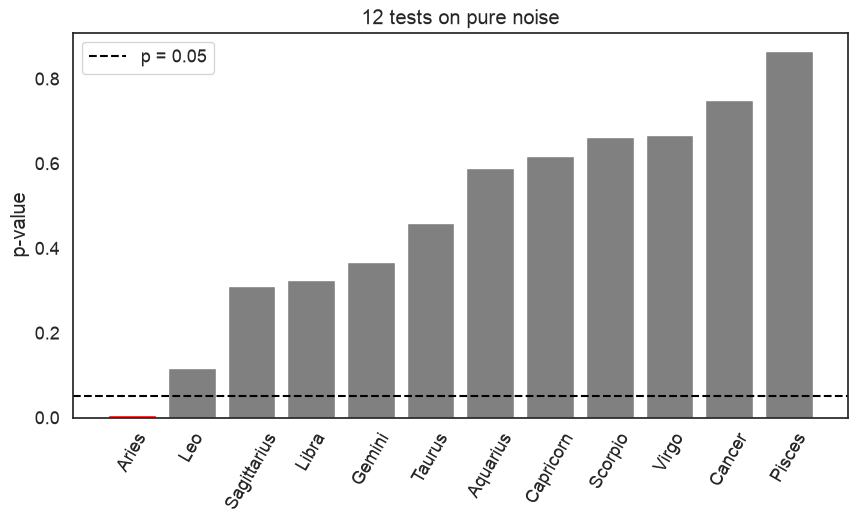

In [15]:
plt.bar(results["sign"], results["p"], color=np.where(results["p"] < 0.05, "red", "grey"))
plt.axhline(0.05, color="black", ls="--", label="p = 0.05")
plt.xticks(rotation=60); plt.ylabel("p-value")
plt.title("12 tests on pure noise")
plt.legend(); plt.show()

### Exercise

1. The star signs were assigned by a random number generator. So what went wrong with the headline?
2. If you run 12 independent tests at $\alpha=0.05$ and every null is true, the probability of at least one false positive is $1-0.95^{12}$. Compute it.
3. The **Bonferroni correction** tests each hypothesis at $\alpha/m$ (here $0.05/12$). Would the headline survive?
4. Name two ways this could happen in real research *without* anyone meaning to cheat (think: many outcomes, many subgroups, trying different control variables, stopping data collection when p < 0.05).

In [16]:
# your code here

### How often does noise look significant?

Let's run 2,000 "studies" in which we split 1,000 random people into two groups by coin flip and t-test their incomes. Every null hypothesis is true.

Share of 'significant' results (p < 0.05): 0.046


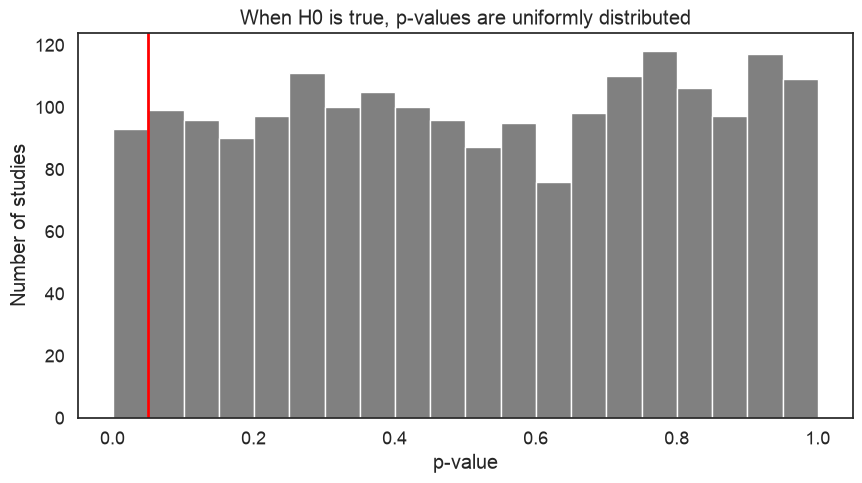

In [17]:
incomes = df["income"].to_numpy()
pvals = []
for i in range(2000):
    x = rng.choice(incomes, size=1000, replace=False)
    group = rng.random(1000) < 0.5
    pvals.append(stats.ttest_ind(x[group], x[~group], equal_var=False).pvalue)
pvals = np.array(pvals)

print(f"Share of 'significant' results (p < 0.05): {(pvals < 0.05).mean():.3f}")
plt.hist(pvals, bins=20, edgecolor="white", color="grey")
plt.axvline(0.05, color="red", lw=2)
plt.xlabel("p-value"); plt.ylabel("Number of studies")
plt.title("When H0 is true, p-values are uniformly distributed")
plt.show()

### Where do null findings go? Publication bias and the winner's curse

Journals are more likely to publish significant results; the rest end up in the "file drawer". What does that do to the effects we read about?

Let's use a **real** effect. In our population, union members earn more than non-members. Imagine many research teams each run a small study (30 members, 30 non-members) and only the significant ones get published.

In [18]:
mem_inc = unions.loc[unions["member"] == 1, "income"].to_numpy()
non_inc = unions.loc[unions["member"] == 0, "income"].to_numpy()
true_premium = mem_inc.mean() - non_inc.mean()

def run_studies(n_per_group, n_studies=3000):
    est, sig = [], []
    for i in range(n_studies):
        a = rng.choice(mem_inc, n_per_group)
        b = rng.choice(non_inc, n_per_group)
        r = stats.ttest_ind(a, b, equal_var=False)
        est.append(a.mean() - b.mean())
        sig.append(r.pvalue < 0.05)
    return np.array(est), np.array(sig)

est, sig = run_studies(30)
print(f"True union premium: {true_premium:.1f}k")
print(f"Share of studies that are significant (the power): {sig.mean():.2f}")
print(f"Average estimate, all studies:       {est.mean():.1f}k")
print(f"Average estimate, published studies: {est[sig].mean():.1f}k")

True union premium: 7.9k
Share of studies that are significant (the power): 0.18
Average estimate, all studies:       7.8k
Average estimate, published studies: 18.6k


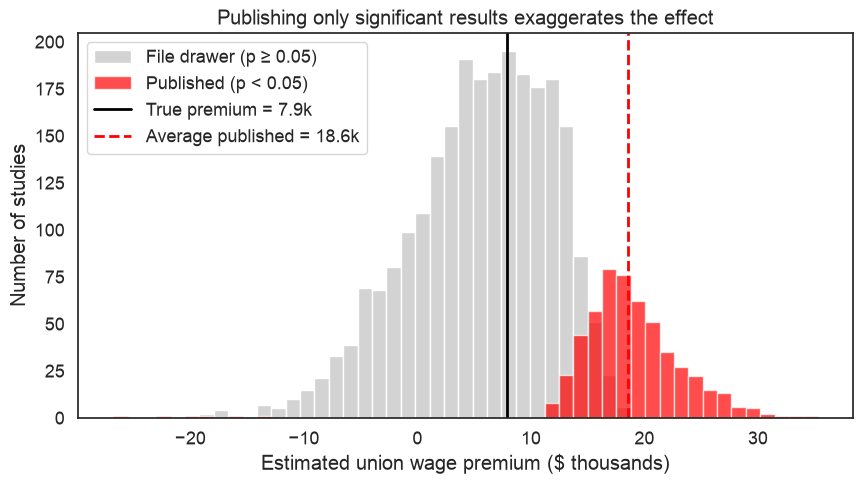

In [19]:
bins = np.linspace(est.min(), est.max(), 50)
plt.hist(est[~sig], bins=bins, color="lightgrey", label="File drawer (p ≥ 0.05)")
plt.hist(est[sig], bins=bins, color="red", alpha=0.7, label="Published (p < 0.05)")
plt.axvline(true_premium, color="black", lw=2, label=f"True premium = {true_premium:.1f}k")
plt.axvline(est[sig].mean(), color="red", ls="--", lw=2, label=f"Average published = {est[sig].mean():.1f}k")
plt.xlabel("Estimated union wage premium ($ thousands)"); plt.ylabel("Number of studies")
plt.title("Publishing only significant results exaggerates the effect")
plt.legend(); plt.show()

### Exercise

1. By how many times does the published literature exaggerate the true premium?
2. Re-run with 300 people per group. What happens to the power and the exaggeration? Why?
3. A meta-analysis averages the published studies. Would it recover the true effect? What would it need to do so?
4. A few published studies found that union members earn *less* (see the red bars left of zero, if any). Why might that happen even though the true effect is positive?

In [20]:
# your code here

## 4. Bayes' theorem: base rates

The lecture's quick question: *a disease affects 1% of people. A test catches 90% of people who have it, but also wrongly flags 9% of healthy people. You test positive. What's the chance you have the disease?*

$$P(A\mid B) = \frac{P(B\mid A)\,P(A)}{P(B)}$$

In [21]:
def posterior_positive(prior, sensitivity, false_positive_rate):
    # P(condition | positive test), by Bayes' theorem
    evidence = sensitivity * prior + false_positive_rate * (1 - prior)
    return sensitivity * prior / evidence

post1 = posterior_positive(0.01, 0.90, 0.09)
print(f"P(sick | one positive test) = {post1:.3f}")
print(f"P(sick | two positive tests) = {posterior_positive(post1, 0.90, 0.09):.3f}   (yesterday's posterior = today's prior)")

P(sick | one positive test) = 0.092
P(sick | two positive tests) = 0.503   (yesterday's posterior = today's prior)


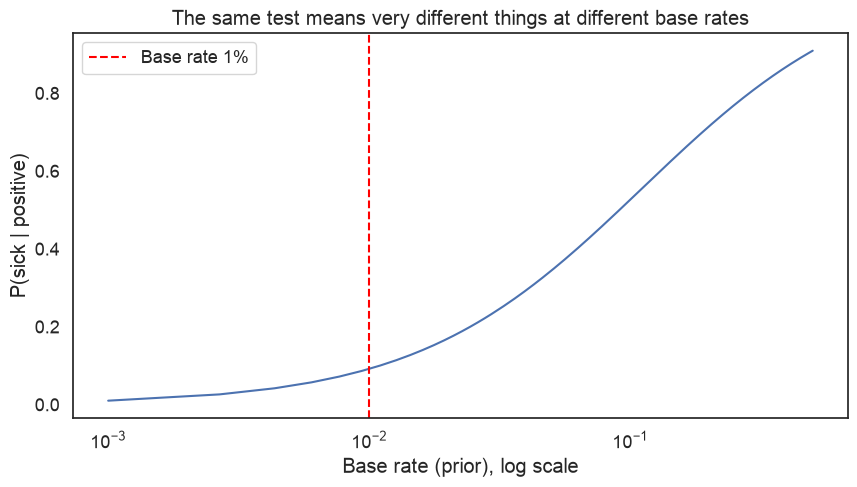

In [22]:
priors = np.linspace(0.001, 0.5, 300)
plt.plot(priors, posterior_positive(priors, 0.90, 0.09))
plt.axvline(0.01, color="red", ls="--", label="Base rate 1%")
plt.xscale("log")
plt.xlabel("Base rate (prior), log scale"); plt.ylabel("P(sick | positive)")
plt.title("The same test means very different things at different base rates")
plt.legend(); plt.show()

### Are most published findings false?

Ioannidis (2005) applied the same logic to research. A "positive test" is a significant result; the "base rate" is the share of tested hypotheses that are actually true.

Lecture example (10% true, 80% power): 36% of discoveries are false


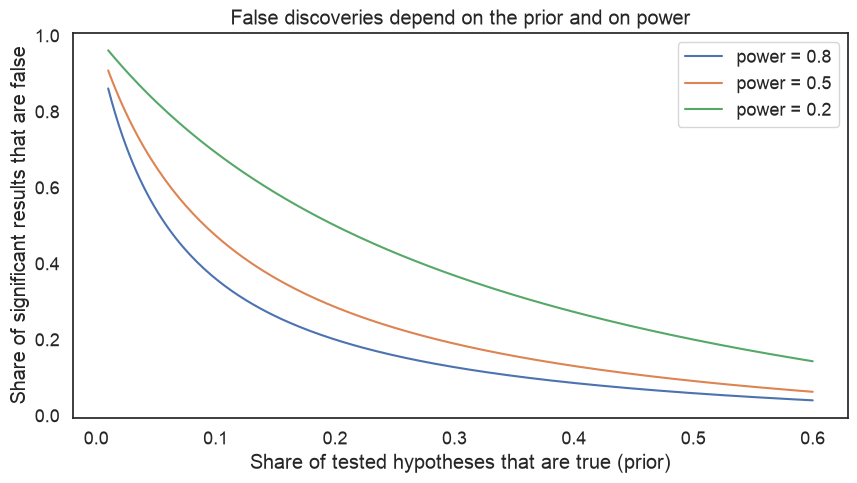

In [23]:
def share_false_discoveries(prior_true, power, alpha=0.05):
    true_pos = power * prior_true
    false_pos = alpha * (1 - prior_true)
    return false_pos / (true_pos + false_pos)

print(f"Lecture example (10% true, 80% power): {share_false_discoveries(0.10, 0.80):.0%} of discoveries are false")

p_true = np.linspace(0.01, 0.6, 200)
for power in [0.8, 0.5, 0.2]:
    plt.plot(p_true, share_false_discoveries(p_true, power), label=f"power = {power}")
plt.xlabel("Share of tested hypotheses that are true (prior)")
plt.ylabel("Share of significant results that are false")
plt.title("False discoveries depend on the prior and on power")
plt.legend(); plt.show()

### Flipping conditionals with real data

The same trap appears in everyday data analysis. Use the CPS to compare two conditional probabilities that sound alike:

* P(works in construction | union member)
* P(union member | works in construction)

In [24]:
tab = pd.crosstab(unions["occupation"], unions["member"], margins=True)
tab.columns = ["non-member", "member", "total"]
tab.tail()

,non-member,member,total
occupation,,,
Production,503,90,593
Protective Service adj_occupations,141,91,232
Transportation and materials moving,403,93,496
financial Operators,204,14,218
All,7468,1229,8697


### Exercise

1. Using `tab`, compute P(construction | member) and P(member | construction) (the occupation is called `"Consruction, Extraction, Installation"` in the data, typo included). Why are they so different? Which one is the "base rate" issue?
2. In the zodiac example above, what was the prior probability that any sign truly affects income? So what share of those "discoveries" were false?
3. The Sally Clark case: an expert said the chance of two cot deaths in one family was "1 in 73 million". Which conditional probability is that? Which one did the jury need, and why does Bayes say the rare alternative (double murder) matters?
4. Using `share_false_discoveries`, what share of significant findings are false in a field with a 5% prior and 20% power (small studies, like our 30-per-group union studies)?

In [25]:
# your code here

## 5. Priors, likelihoods and posteriors: union membership again

In Workshop 5 we estimated union membership from samples. As in the lecture, suppose we can only interview **7 people** and **none** of them is a union member. The frequentist estimate is 0/7 = 0%, and the normal-approximation 95% CI is "0% to 0%". Nobody believes that.

Bayesian inference lets us add what we knew beforehand, the **prior**, and combine it with the data, the **likelihood**, to get the **posterior**:

$$\text{posterior} \propto \text{likelihood} \times \text{prior}$$

### The Beta distribution

For a proportion $\theta$ between 0 and 1, the standard prior is $\text{Beta}(a, b)$, with mean $a/(a+b)$. Think of $a-1$ as prior "successes" and $b-1$ as prior "failures".

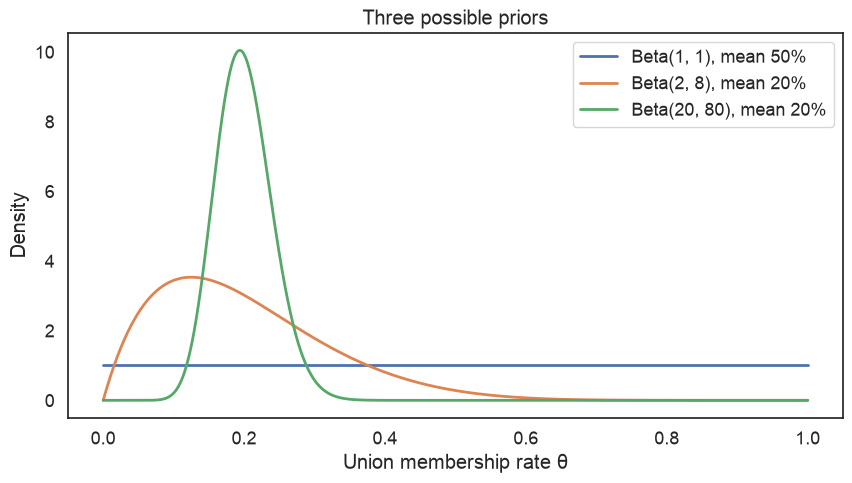

In [26]:
theta = np.linspace(0, 1, 1001)
for a, b in [(1, 1), (2, 8), (20, 80)]:
    plt.plot(theta, stats.beta.pdf(theta, a, b), lw=2, label=f"Beta({a}, {b}), mean {a/(a+b):.0%}")
plt.xlabel("Union membership rate θ"); plt.ylabel("Density")
plt.title("Three possible priors")
plt.legend(); plt.show()

### Updating is just counting

With a Beta(a, b) prior and k successes in n trials, the posterior is

$$\text{Beta}(a + k,\; b + n - k)$$

Let's use the weakly informative Beta(2, 8) prior ("probably low, but I'm not sure") and the data 0 of 7.

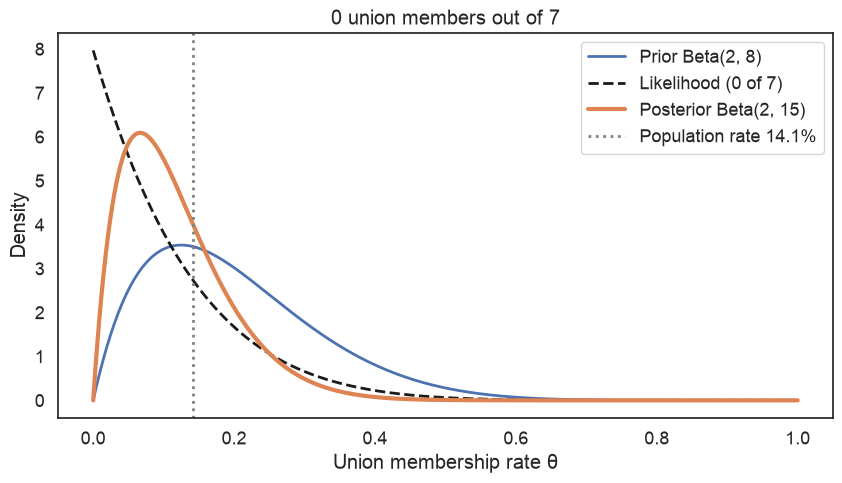

Posterior mean 11.8%, 95% credible interval 1.6% to 30.2%


In [27]:
def update(a, b, k, n):
    return a + k, b + n - k

def plot_update(a, b, k, n, true_rate=None, ax=None):
    ax = ax or plt.gca()
    a_post, b_post = update(a, b, k, n)
    prior = stats.beta.pdf(theta, a, b)
    likelihood = stats.binom.pmf(k, n, theta)
    likelihood = likelihood / likelihood.sum() * (len(theta) - 1)   # rescale so it fits on the same axes
    posterior = stats.beta.pdf(theta, a_post, b_post)
    ax.plot(theta, prior, lw=2, label=f"Prior Beta({a}, {b})")
    ax.plot(theta, likelihood, "k--", lw=2, label=f"Likelihood ({k} of {n})")
    ax.plot(theta, posterior, lw=3, label=f"Posterior Beta({a_post}, {b_post})")
    if true_rate is not None:
        ax.axvline(true_rate, color="grey", ls=":", lw=2, label=f"Population rate {true_rate:.1%}")
    ax.set(xlabel="Union membership rate θ", ylabel="Density")
    ax.legend()
    return stats.beta(a_post, b_post)

p_true = unions["member"].mean()
post = plot_update(2, 8, k=0, n=7, true_rate=p_true)
plt.title("0 union members out of 7"); plt.show()

lo, hi = post.ppf([0.025, 0.975])
print(f"Posterior mean {post.mean():.1%}, 95% credible interval {lo:.1%} to {hi:.1%}")

The likelihood alone peaks at 0%. The prior pulls the estimate towards plausible values, and the posterior is a compromise weighted by how much information each carries.

### More data, less prior

Now take a random sample of 1,000 people from `unions`.

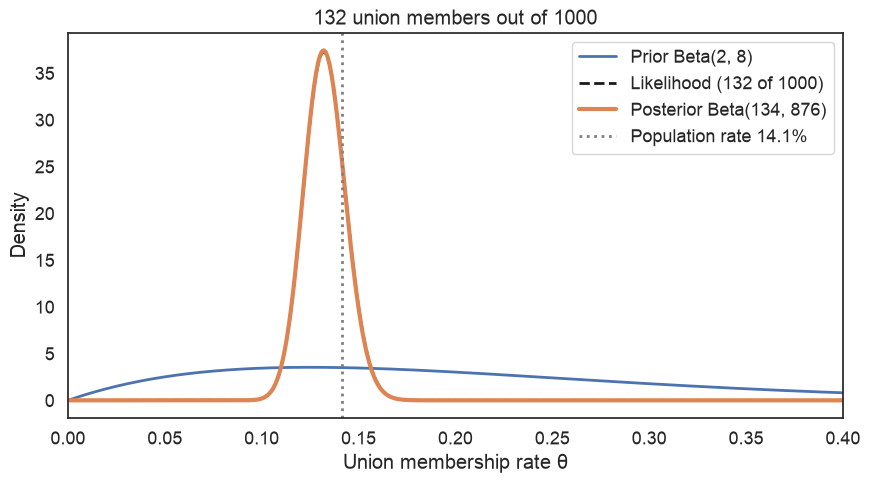

95% credible interval (Bayesian):   0.112 to 0.154
95% confidence interval (frequentist): 0.111 to 0.153


In [28]:
big = unions["member"].sample(1000, random_state=11)
k, n = int(big.sum()), len(big)

post = plot_update(2, 8, k=k, n=n, true_rate=p_true)
plt.xlim(0, 0.4); plt.title(f"{k} union members out of {n}"); plt.show()

cred = post.ppf([0.025, 0.975])
p_hat = k / n
se = np.sqrt(p_hat * (1 - p_hat) / n)
conf = [p_hat - 1.96 * se, p_hat + 1.96 * se]
print(f"95% credible interval (Bayesian):   {cred[0]:.3f} to {cred[1]:.3f}")
print(f"95% confidence interval (frequentist): {conf[0]:.3f} to {conf[1]:.3f}")

With 1,000 observations the likelihood is sharp and overwhelms the prior, so the two intervals are almost identical. Just like the CLT, uncertainty shrinks as n grows.

### Exercise: does the prior matter?

1. Make a 2 x 3 grid of plots (`fig, axes = plt.subplots(2, 3, figsize=(16, 8))`): rows are sample sizes n = 20 and n = 1,000 (draw them from `unions["member"]`), columns are the priors Beta(1, 1), Beta(2, 8) and a strong, *wrong* prior Beta(50, 50) centred on 50%. Use `plot_update(..., ax=axes[i, j])`.
2. With n = 20, how different are the three posteriors? With n = 1,000?
3. For each case, compute the 95% credible interval. Which posteriors contain the population rate?
4. Write one sentence of advice about when priors matter.

In [29]:
# your code here

### (Optional) Today's posterior is tomorrow's prior

Start from a flat Beta(1, 1) prior and update in batches of 50 respondents, using each posterior as the next prior. Plot the posterior mean and 95% credible interval against the number of respondents seen. Check that after all batches you get exactly the same posterior as updating with all the data at once.

In [30]:
# your code here

## 6. Confidence vs credible intervals

|  | 95% confidence interval | 95% credible interval |
|---|---|---|
| θ is... | a fixed, unknown number | a random variable with a distribution |
| Randomness comes from | the sampling process | our uncertainty about θ |
| Correct interpretation | if we repeated the study many times, 95% of intervals would contain θ | given the data and prior, there's a 95% probability θ is in this interval |
| Needs a prior? | no | yes |
| Lots of data, weak prior | nearly identical numbers | nearly identical numbers |

### Exercise

1. For the 0-of-7 sample, compare the normal-approximation confidence interval with the Beta(2, 8) credible interval. Which is more useful? What did the Bayesian have to assume to get it?
2. Your friend reads the 1,000-person confidence interval above and says "so there's a 95% chance union membership is between those two numbers". Is that a correct statement about the confidence interval? About the credible interval?
3. Bayesian methods shine with small samples. Using `unions`, pick the occupation with the fewest respondents and estimate its union membership rate with (a) a frequentist 95% CI and (b) a Beta(2, 8) posterior and 95% credible interval. Which would you report to a policymaker, and how would you explain your prior?

In [31]:
# your code here

## Recap

1. A **95% confidence interval** is $\bar{x} \pm 1.96\,SE$: the procedure captures the true value in 95% of repeated samples.
2. A **t-test** divides a difference in means (signal) by its standard error (noise). Four steps: hypotheses, $\alpha$ and critical value, test statistic, decision.
3. **Statistical significance is not truth.** Test enough hypotheses and 5% of nulls come out significant; publish only significant results and effect sizes are exaggerated.
4. **Bayes' theorem** flips conditional probabilities; base rates matter. A p-value is P(data | $H_0$), not P($H_0$ | data).
5. With a **Beta prior** and binomial data, the posterior is Beta(a + k, b + n − k). Priors matter most when data are scarce; with lots of data, credible and confidence intervals nearly agree.